<a href="https://colab.research.google.com/github/arpita0911/ML-DL-Lab/blob/main/exp_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Neural Network

Handwritten digit classification on the MNIST dataset using a basic neural network, followed by tuning layers , neurons, and learning rates, and comparing regularization methods like dropout, L1, and L2 to control overfitting.

In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras  import layers,models,callbacks
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

In [15]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

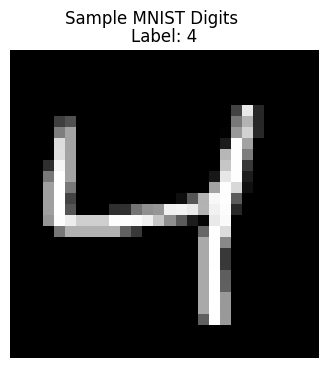

In [16]:
plt.figure(figsize=(10,4))
plt.imshow(x_train[2], cmap="gray")
plt.title(f"Label: {y_train[2]}")
plt.axis(False)
plt.suptitle("Sample MNIST Digits")
plt.show()

In [17]:
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

## Simple ANN

In [18]:
def build_model(num_layers, neurons, lr):
    model = models.Sequential()
    model.add(layers.Input(shape=(784,)))

    for _ in range(num_layers):
        model.add(layers.Dense(neurons, activation="relu"))

    model.add(layers.Dense(10, activation="softmax"))
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [22]:
layer_options = [3, 5, 7]
neuron_options = [8, 16, 32, 64]
lr_options = [0.001, 0.01, 0.0001]
results = []

best_val_acc = 0
best_model = None
best_params = None

for num_layers in layer_options:
    for neurons in neuron_options:
        for lr in lr_options:

            print(f"\nTraining: Layers={num_layers}, Neurons={neurons}, LR={lr}")

            model = build_model(num_layers, neurons, lr)

            start_time = time.time()

            history = model.fit(
                x_train, y_train,
                validation_data=(x_test, y_test),
                epochs=10,
                batch_size=128,
                verbose=0
            )

            end_time = time.time()
            train_time = end_time - start_time

            train_acc = history.history["accuracy"][-1]
            val_acc = history.history["val_accuracy"][-1]

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model = model
                best_params = (num_layers, neurons, lr)

            results.append({
                "Layers": num_layers,
                "Neurons": neurons,
                "Learning Rate": lr,
                "Train Accuracy": round(train_acc, 4),
                "Val Accuracy": round(val_acc, 4),
                "Training Time (s)": round(train_time, 2)
            })



Training: Layers=3, Neurons=8, LR=0.001

Training: Layers=3, Neurons=8, LR=0.01

Training: Layers=3, Neurons=8, LR=0.0001

Training: Layers=3, Neurons=16, LR=0.001

Training: Layers=3, Neurons=16, LR=0.01

Training: Layers=3, Neurons=16, LR=0.0001

Training: Layers=3, Neurons=32, LR=0.001

Training: Layers=3, Neurons=32, LR=0.01

Training: Layers=3, Neurons=32, LR=0.0001

Training: Layers=3, Neurons=64, LR=0.001

Training: Layers=3, Neurons=64, LR=0.01

Training: Layers=3, Neurons=64, LR=0.0001

Training: Layers=5, Neurons=8, LR=0.001

Training: Layers=5, Neurons=8, LR=0.01

Training: Layers=5, Neurons=8, LR=0.0001

Training: Layers=5, Neurons=16, LR=0.001

Training: Layers=5, Neurons=16, LR=0.01

Training: Layers=5, Neurons=16, LR=0.0001

Training: Layers=5, Neurons=32, LR=0.001

Training: Layers=5, Neurons=32, LR=0.01

Training: Layers=5, Neurons=32, LR=0.0001

Training: Layers=5, Neurons=64, LR=0.001

Training: Layers=5, Neurons=64, LR=0.01

Training: Layers=5, Neurons=64, LR=0.000

In [23]:
df_results = pd.DataFrame(results)
df_results.sort_values(by="Val Accuracy", ascending=False, inplace=True)
df_results.head(40)

,Layers,Neurons,Learning Rate,Train Accuracy,Val Accuracy,Training Time (s)
33,7,64,0.0010,0.9866,0.9734,21.54
21,5,64,0.0010,0.9866,0.9714,21.32
9,3,64,0.0010,0.9882,0.9713,19.07
22,5,64,0.0100,0.9790,0.9705,22.00
18,5,32,0.0010,0.9769,0.9691,23.00
10,3,64,0.0100,0.9791,0.9660,20.65
6,3,32,0.0010,0.9786,0.9645,22.51
30,7,32,0.0010,0.9754,0.9621,21.10
19,5,32,0.0100,0.9699,0.9611,22.98
35,7,64,0.0001,0.9628,0.9593,23.01


In [24]:
def train_model(model, title, x_train, y_train, x_val=None, y_val=None, epochs=20):
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    if x_val is not None and y_val is not None:
        history = model.fit(
            x_train, y_train,
            validation_data=(x_val, y_val),
            epochs=epochs,
            batch_size=128,
            verbose=1
        )
    else:
        history = model.fit(
            x_train, y_train,
            validation_split=0.2,
            epochs=epochs,
            batch_size=128,
            verbose=1
        )

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(title + " Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(title + " Accuracy")
    plt.legend()

    plt.show()

    return history

## Overfit Model

In [ ]:
x_train_small = x_train[:2000]
y_train_small = y_train[:2000]

x_val = x_train[2000:10000]
y_val = y_train[2000:10000]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 168ms/step - accuracy: 0.5120 - loss: 1.3866 - val_accuracy: 0.7928 - val_loss: 0.6367
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8760 - loss: 0.4268 - val_accuracy: 0.8779 - val_loss: 0.4175
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9420 - loss: 0.2058 - val_accuracy: 0.8971 - val_loss: 0.3961
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9645 - loss: 0.1240 - val_accuracy: 0.8994 - val_loss: 0.4076
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9715 - loss: 0.1031 - val_accuracy: 0.8838 - val_loss: 0.4544
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9595 - loss: 0.1226 - val_accuracy: 0.8850 - val_loss: 0.4695
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9730 - loss: 0.0959 - val_accuracy: 0.9130 - val_loss: 0.3701
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9820 - loss: 0.0601 - val_accuracy: 0

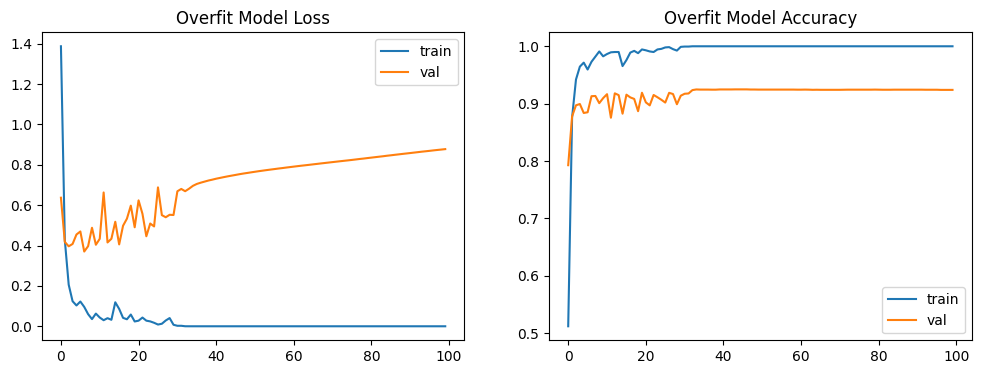

In [ ]:
def build_overfit_model():
    model = keras.Sequential([
        layers.Dense(1024, activation='relu', input_shape=(784,)),
        layers.Dense(1024, activation='relu'),
        layers.Dense(1024, activation='relu'),
        layers.Dense(1024, activation='relu'),
        layers.Dense(1024, activation='relu'),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

overfit_model = build_overfit_model()
history_overfit = train_model(overfit_model, "Overfit Model",x_train_small, y_train_small, x_val, y_val, epochs=100)

## Dropout Model

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8531 - loss: 0.4607 - val_accuracy: 0.9563 - val_loss: 0.1460
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9381 - loss: 0.2050 - val_accuracy: 0.9658 - val_loss: 0.1154
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9521 - loss: 0.1603 - val_accuracy: 0.9698 - val_loss: 0.1011
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9591 - loss: 0.1385 - val_accuracy: 0.9723 - val_loss: 0.0930
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9634 - loss: 0.1229 - val_accuracy: 0.9728 - val_loss: 0.0901
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9677 - loss: 0.1102 - val_accuracy: 0.9761 - val_loss: 0.0834
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9705 - loss: 0.0978 - val_accuracy: 0.9749 - val_loss: 0.0863
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9701 - loss: 0.0976 - val_accuracy: 0.

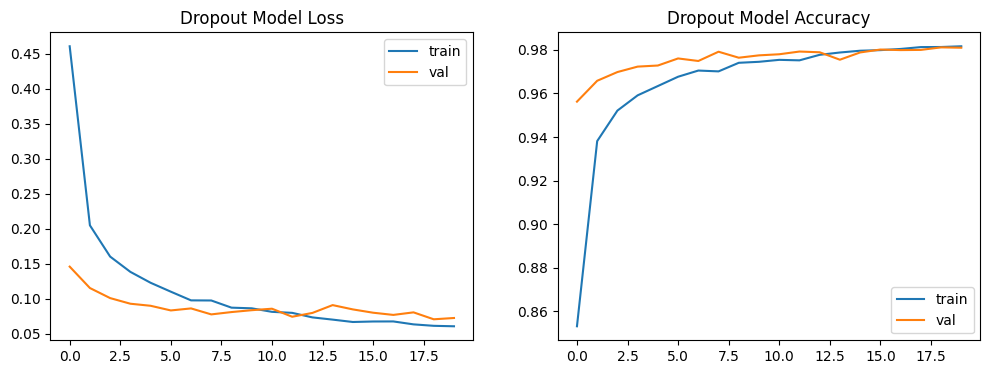

In [ ]:
def build_dropout_model():
    model = keras.Sequential([
        layers.Dense(512, activation='relu', input_shape=(784,)),
        layers.Dropout(0.5),

        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(10, activation='softmax')
    ])
    return model

dropout_model = build_dropout_model()
history_dropout = train_model(dropout_model, "Dropout Model", x_train, y_train)

## L1 Regularization

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8565 - loss: 4.7512 - val_accuracy: 0.8923 - val_loss: 1.1349
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8944 - loss: 0.9842 - val_accuracy: 0.9137 - val_loss: 0.8422
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9119 - loss: 0.8012 - val_accuracy: 0.9223 - val_loss: 0.7314
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9240 - loss: 0.7105 - val_accuracy: 0.9333 - val_loss: 0.6661
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9304 - loss: 0.6505 - val_accuracy: 0.9334 - val_loss: 0.6349
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9344 - loss: 0.6146 - val_accuracy: 0.9419 - val_loss: 0.5846
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9370 - loss: 0.5837 - val_accuracy: 0.9423 - val_loss: 0.5635
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9408 - loss: 0.5619 - val_accuracy: 0.

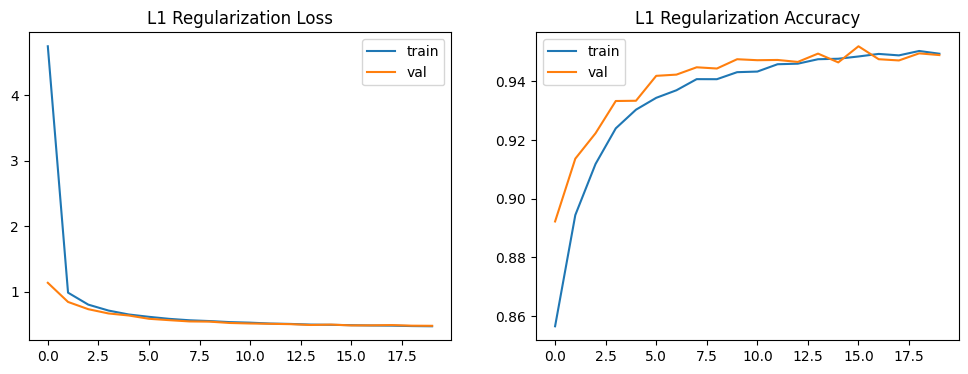

In [ ]:
def build_l1_model():
    model = keras.Sequential([
        layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l1(0.001),
                     input_shape=(784,)),

        layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l1(0.001)),

        layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l1(0.001)),

        layers.Dense(10, activation='softmax')
    ])
    return model

l1_model = build_l1_model()
history_l1 = train_model(l1_model, "L1 Regularization",x_train, y_train)

## L2 Regularization

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9236 - loss: 0.9682 - val_accuracy: 0.9502 - val_loss: 0.5458
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9607 - loss: 0.4070 - val_accuracy: 0.9647 - val_loss: 0.3216
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9685 - loss: 0.2774 - val_accuracy: 0.9697 - val_loss: 0.2551
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9709 - loss: 0.2363 - val_accuracy: 0.9674 - val_loss: 0.2402
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9735 - loss: 0.2151 - val_accuracy: 0.9718 - val_loss: 0.2121
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9759 - loss: 0.1956 - val_accuracy: 0.9696 - val_loss: 0.2134
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9775 - loss: 0.1834 - val_accuracy: 0.9718 - val_loss: 0.2004
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9791 - loss: 0.1743 - val_accuracy: 0.

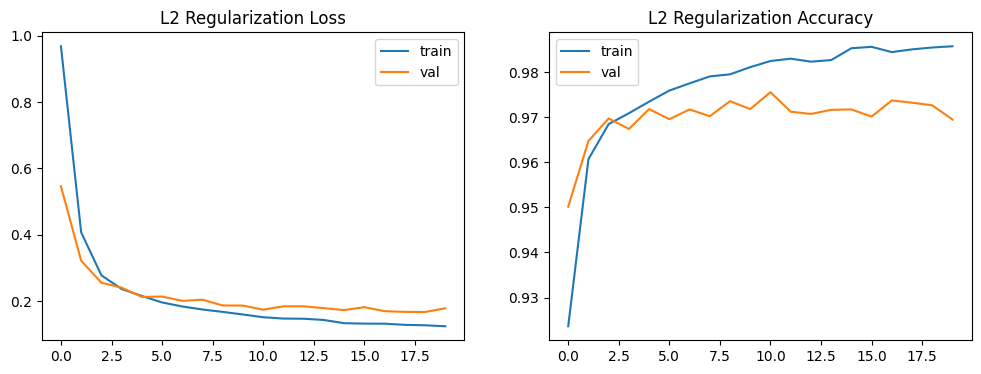

In [ ]:
def build_l2_model():
    model = keras.Sequential([
        layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001),
                     input_shape=(784,)),

        layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),

        layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),

        layers.Dense(10, activation='softmax')
    ])
    return model

l2_model = build_l2_model()
history_l2 = train_model(l2_model, "L2 Regularization",x_train, y_train)

## Comparison

In [ ]:
def compare_models(histories, labels):
    plt.figure(figsize=(10,5))

    summary = []

    for history, label in zip(histories, labels):
        val_acc = history.history['val_accuracy']
        train_acc = history.history['accuracy']
        val_loss = history.history['val_loss']
        train_loss = history.history['loss']

        plt.plot(val_acc, label=label)

        final_train_acc = train_acc[-1]
        final_val_acc = val_acc[-1]
        best_val_acc = max(val_acc)
        final_train_loss = train_loss[-1]
        final_val_loss = val_loss[-1]
        gap = final_train_acc - final_val_acc

        summary.append([
            label,
            round(final_train_acc, 4),
            round(final_val_acc, 4),
            round(best_val_acc, 4),
            round(final_train_loss, 4),
            round(final_val_loss, 4),
            round(gap, 4)
        ])

    plt.title("Validation Accuracy Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    import pandas as pd

    df = pd.DataFrame(summary, columns=[
        "Model", "Train Acc", "Val Acc", "Best Val Acc",
        "Train Loss", "Val Loss", "Gap"
    ])

    return df

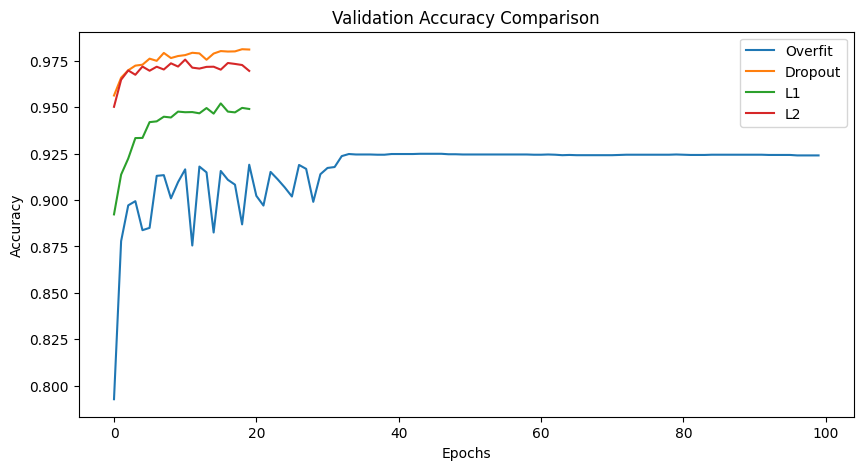

In [ ]:
df=compare_models(
    [history_overfit, history_dropout, history_l1, history_l2],
    ["Overfit", "Dropout", "L1", "L2"]
)


In [ ]:
df.head()

,Model,Train Acc,Val Acc,Best Val Acc,Train Loss,Val Loss,Gap
0,Overfit,1.0000,0.9240,0.9249,0.0000,0.8773,0.0760
1,Dropout,0.9817,0.9810,0.9812,0.0608,0.0726,0.0007
2,L1,0.9495,0.9490,0.9520,0.4701,0.4773,0.0005
3,L2,0.9858,0.9695,0.9756,0.1237,0.1779,0.0163
